In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install transformers

In [ ]:
from IPython.display import clear_output
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertConfig, get_linear_schedule_with_warmup
from tqdm import tqdm, trange
import pandas as pd
import io
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from pprint import pprint
import json

In [ ]:
def new_dataset(file_name):
    with open(file_name, 'r') as json_file:
            json_list = list(json_file)
            my_dataset = []
            for json_str in json_list:
                item = json.loads(json_str)
                # {'premise': 'The photo albums collected dust in the attic и тд

                # строим новый датасет
                premise = item["premise"]

                if item["label"] == 0: #если верна первая гипотеза
                    new = {}
                    new["premise"] = premise       

                    hypothesis = item["choice1"] 
                    label = 1

                    new["hypothesis"] = hypothesis
                    new["label"] = label
                    
                    my_dataset.append(new)

                    #добавляем словарь со второй гипотезой 

                    new_2 = {}
                    new_2["premise"] = premise

                    hypothesis = item["choice2"] 
                    label = 0
                    
                    new_2["hypothesis"] = hypothesis
                    new_2["label"] = label

                    my_dataset.append(new_2)

                else: 
                    #если верна вторая гипотеза
                    new = {}
                    new["premise"] = premise       

                    hypothesis = item["choice2"] 
                    label = 1 

                    new["hypothesis"] = hypothesis
                    new["label"] = label
                    
                    my_dataset.append(new) 

                    #добавляем словарь со второй гипотезой 

                    new_2 = {}
                    new_2["premise"] = premise

                    hypothesis = item["choice1"] 
                    label = 0
                    
                    new_2["hypothesis"] = hypothesis
                    new_2["label"] = label
                  
                    my_dataset.append(new_2)
               
    return my_dataset


In [ ]:
train = new_dataset('/content/drive/MyDrive/The_final/COPA/train.jsonl') 
valid = new_dataset('/content/drive/MyDrive/The_final/COPA/val.jsonl')

In [ ]:
train = train + valid
len(train)

In [ ]:
train_sentences = []
train_labels = []
for el in train:
  train_sentences.append(el['hypothesis'] + el['premise'])
  train_labels.append(el['label'])

valid_sentences = []
valid_labels = []
for el in valid:
  valid_sentences.append(el['hypothesis'] + el['premise'])
  valid_labels.append(el['label'])

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from transformers import DebertaTokenizer, DebertaForSequenceClassification

tokenizer = DebertaTokenizer.from_pretrained('microsoft/deberta-base', do_lower_case=True)

input_ids = [tokenizer.tokenize(sent) for sent in train_sentences]

#обрезка тут не нужна
print(input_ids[0]) #в отличии от берта возвращает не список слов, а список номеров в словаре

In [ ]:
from keras.preprocessing.sequence import pad_sequences

input_ids = pad_sequences(
    input_ids,
    maxlen=512,
    dtype="long",
    truncating="post",
    padding="post"
)
attention_masks = [[float(i>0) for i in seq] for seq in input_ids]

In [ ]:
test_SIZE = 0.1
BATCH = 4
batch_size = BATCH


train_inputs, validation_inputs, train_labels, validation_labels = train_test_split(
    input_ids, train_labels, 
    random_state=42,
    test_size = test_SIZE)

train_masks, validation_masks, _, _ = train_test_split(
    attention_masks,
    input_ids,
    random_state=42,
    test_size=test_SIZE
)

train_inputs = torch.tensor(train_inputs)
train_labels = torch.tensor(train_labels)
train_masks = torch.tensor(train_masks)

validation_inputs = torch.tensor(validation_inputs)
validation_labels = torch.tensor(validation_labels)
validation_masks = torch.tensor(validation_masks)


In [ ]:
train_data = TensorDataset(train_inputs, train_masks, train_labels)

train_dataloader = DataLoader(
    train_data,
    sampler=RandomSampler(train_data),
    batch_size=batch_size
)

validation_data = TensorDataset(validation_inputs, validation_masks, validation_labels)

validation_dataloader = DataLoader(
    validation_data,
    sampler=SequentialSampler(validation_data),
    batch_size=batch_size
)

In [ ]:
from transformers import AdamW

model = DebertaForSequenceClassification.from_pretrained('microsoft/deberta-base')
model.to(device)

In [ ]:
def train(model, 
             optimizer, 
             train_dataloader, 
             validation_dataloader, 
             scheduler,
             num_epochs):
  
  train_loss_set = []
  train_loss = 0

  for epoch in range(num_epochs):
    model.train()


    for step, batch in enumerate(train_dataloader):
        batch = tuple(t.to(device) for t in batch)
        b_input_ids, b_input_mask, b_labels = batch
        optimizer.zero_grad()
        
        
        loss = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
        train_loss_set.append(loss[0].item())  
        
        
        loss[0].backward()
        scheduler.step()
        optimizer.step()

        train_loss += loss[0].item()
        
        clear_output(True)
        plt.plot(train_loss_set)
        plt.title("Training loss")
        plt.xlabel("Batch")
        plt.ylabel("Loss")
        plt.show()
    
    model.eval()

    valid_preds, valid_labels = [], []

    for batch in validation_dataloader:   
        batch = tuple(t.to(device) for t in batch)
        
        b_input_ids, b_input_mask, b_labels = batch
        
        with torch.no_grad():
            logits = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

        logits = logits[0].detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()
        
    #     batch_preds = np.argmax(logits, axis=1)
    #     batch_labels = np.concatenate(label_ids)     
    #     valid_preds.extend(batch_preds)
    #     valid_labels.extend(batch_labels)

    # print("accuracy score {0:.2f}%".format(
    #     accuracy_score(valid_labels, valid_preds) * 100
    # ))
    # print("F1: {0:.2f}%".format(
    #   f1_score(valid_labels, valid_preds, average='weighted') * 100
    # ))

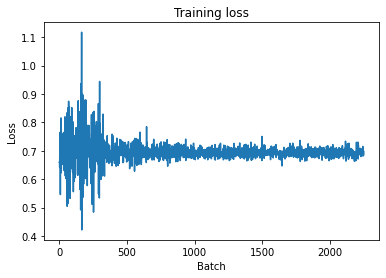

In [ ]:
optimizer = AdamW(model.parameters(), lr=1e-5)
NUM_EPOCHS = 10



scheduler = get_linear_schedule_with_warmup(optimizer, 
                                            num_warmup_steps=len(train_dataloader), 
                                            num_training_steps=len(train_dataloader)*NUM_EPOCHS)

train(model=model,
      optimizer=optimizer,
      scheduler=scheduler,
      train_dataloader=train_dataloader,
      validation_dataloader=validation_dataloader,
      num_epochs=NUM_EPOCHS)

In [ ]:
import torch.nn.functional as F
from sklearn import metrics

acc = []


model.eval()



test_preds, test_labels = [], []

for batch in validation_dataloader:
    batch = tuple(t.to(device) for t in batch)
    
    b_input_ids, b_input_mask, b_labels  = batch
  
    
    with torch.no_grad():
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)

    logits = outputs[0]
    prediction = torch.argmax(logits, dim=1)
    targets = b_labels.cpu().detach().numpy()
    prediction = prediction.cpu().detach().numpy()
    accuracy = metrics.accuracy_score(targets, prediction)

    acc.append(accuracy)

print(sum(acc)/len(acc))

0.5
